In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ Libraries ready!')

✅ Libraries ready!


In [2]:
df = pd.read_csv('financial_loan.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Shape: (38576, 24)

Columns: ['id', 'address_state', 'application_type', 'emp_length', 'emp_title', 'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date', 'last_payment_date', 'loan_status', 'next_payment_date', 'member_id', 'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income', 'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc', 'total_payment']


,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [3]:
df['issue_date'] = pd.to_datetime(df['issue_date'], format='%d-%m-%Y')
df['last_payment_date'] = pd.to_datetime(df['last_payment_date'], format='%d-%m-%Y')
df['last_credit_pull_date'] = pd.to_datetime(df['last_credit_pull_date'], format='%d-%m-%Y')

df['month'] = df['issue_date'].dt.month
df['month_name'] = df['issue_date'].dt.strftime('%B')
df['year'] = df['issue_date'].dt.year

df['int_rate_pct'] = df['int_rate'] * 100
df['dti_pct'] = df['dti'] * 100

print('✅ Data Cleaning Done!')
df[['issue_date', 'month', 'month_name', 'int_rate_pct', 'dti_pct']].head()

✅ Data Cleaning Done!


,issue_date,month,month_name,int_rate_pct,dti_pct
0,2021-02-11,2,February,15.27,1.00
1,2021-01-01,1,January,18.64,5.35
2,2021-01-05,1,January,15.96,20.88
3,2021-02-25,2,February,10.65,5.40
4,2021-01-01,1,January,6.03,2.31


In [4]:
total_apps     = df['id'].count()
total_funded   = df['loan_amount'].sum()
total_received = df['total_payment'].sum()
avg_int_rate   = df['int_rate_pct'].mean()
avg_dti        = df['dti_pct'].mean()

mtd  = df[df['month'] == 12]
pmtd = df[df['month'] == 11]

mtd_apps  = mtd['id'].count()
pmtd_apps = pmtd['id'].count()

mtd_funded  = mtd['loan_amount'].sum()
pmtd_funded = pmtd['loan_amount'].sum()

mtd_received  = mtd['total_payment'].sum()
pmtd_received = pmtd['total_payment'].sum()

mtd_int_rate  = mtd['int_rate_pct'].mean()
pmtd_int_rate = pmtd['int_rate_pct'].mean()

mtd_dti  = mtd['dti_pct'].mean()
pmtd_dti = pmtd['dti_pct'].mean()

def mom_change(mtd_val, pmtd_val):
    if pmtd_val == 0:
        return 0
    return round(((mtd_val - pmtd_val) / pmtd_val) * 100, 2)

kpi_summary = pd.DataFrame({
    'KPI': ['Loan Applications', 'Funded Amount', 'Amount Received', 'Avg Interest Rate %', 'Avg DTI %'],
    'Total':  [total_apps, total_funded, total_received, round(avg_int_rate,2), round(avg_dti,2)],
    'MTD':    [mtd_apps, mtd_funded, mtd_received, round(mtd_int_rate,2), round(mtd_dti,2)],
    'PMTD':   [pmtd_apps, pmtd_funded, pmtd_received, round(pmtd_int_rate,2), round(pmtd_dti,2)],
    'MoM Change %': [
        mom_change(mtd_apps, pmtd_apps),
        mom_change(mtd_funded, pmtd_funded),
        mom_change(mtd_received, pmtd_received),
        mom_change(mtd_int_rate, pmtd_int_rate),
        mom_change(mtd_dti, pmtd_dti)
    ]
})

print('📊 KPI Summary:')
kpi_summary

📊 KPI Summary:


,KPI,Total,MTD,PMTD,MoM Change %
0,Loan Applications,3.857600e+04,4314.00,4035.00,6.91
1,Funded Amount,4.357571e+08,53981425.00,47754825.00,13.04
2,Amount Received,4.730709e+08,58074380.00,50132030.00,15.84
3,Avg Interest Rate %,1.205000e+01,12.36,11.94,3.47
4,Avg DTI %,1.333000e+01,13.67,13.30,2.73


In [5]:
total_apps     = df['id'].count()
total_funded   = df['loan_amount'].sum()
total_received = df['total_payment'].sum()
avg_int_rate   = df['int_rate_pct'].mean()
avg_dti        = df['dti_pct'].mean()

mtd  = df[df['month'] == 12]
pmtd = df[df['month'] == 11]

mtd_apps  = mtd['id'].count()
pmtd_apps = pmtd['id'].count()

mtd_funded  = mtd['loan_amount'].sum()
pmtd_funded = pmtd['loan_amount'].sum()

mtd_received  = mtd['total_payment'].sum()
pmtd_received = pmtd['total_payment'].sum()

mtd_int_rate  = mtd['int_rate_pct'].mean()
pmtd_int_rate = pmtd['int_rate_pct'].mean()

mtd_dti  = mtd['dti_pct'].mean()
pmtd_dti = pmtd['dti_pct'].mean()

def mom_change(mtd_val, pmtd_val):
    if pmtd_val == 0:
        return 0
    return round(((mtd_val - pmtd_val) / pmtd_val) * 100, 2)

kpi_summary = pd.DataFrame({
    'KPI': ['Loan Applications', 'Funded Amount', 'Amount Received', 'Avg Interest Rate %', 'Avg DTI %'],
    'Total':  [total_apps, total_funded, total_received, round(avg_int_rate,2), round(avg_dti,2)],
    'MTD':    [mtd_apps, mtd_funded, mtd_received, round(mtd_int_rate,2), round(mtd_dti,2)],
    'PMTD':   [pmtd_apps, pmtd_funded, pmtd_received, round(pmtd_int_rate,2), round(pmtd_dti,2)],
    'MoM Change %': [
        mom_change(mtd_apps, pmtd_apps),
        mom_change(mtd_funded, pmtd_funded),
        mom_change(mtd_received, pmtd_received),
        mom_change(mtd_int_rate, pmtd_int_rate),
        mom_change(mtd_dti, pmtd_dti)
    ]
})

print('📊 KPI Summary:')
kpi_summary

📊 KPI Summary:


,KPI,Total,MTD,PMTD,MoM Change %
0,Loan Applications,3.857600e+04,4314.00,4035.00,6.91
1,Funded Amount,4.357571e+08,53981425.00,47754825.00,13.04
2,Amount Received,4.730709e+08,58074380.00,50132030.00,15.84
3,Avg Interest Rate %,1.205000e+01,12.36,11.94,3.47
4,Avg DTI %,1.333000e+01,13.67,13.30,2.73


In [6]:
good_loans = df[df['loan_status'].isin(['Fully Paid', 'Current'])]
bad_loans  = df[df['loan_status'] == 'Charged Off']

good_pct = round((len(good_loans) / len(df)) * 100, 2)
bad_pct  = round((len(bad_loans)  / len(df)) * 100, 2)

loan_quality = pd.DataFrame({
    'Category': ['Good Loan', 'Bad Loan'],
    'Applications': [len(good_loans), len(bad_loans)],
    'Percentage %': [good_pct, bad_pct],
    'Funded Amount': [good_loans['loan_amount'].sum(), bad_loans['loan_amount'].sum()],
    'Amount Received': [good_loans['total_payment'].sum(), bad_loans['total_payment'].sum()]
})

print('✅ Good vs Bad Loan:')
loan_quality

✅ Good vs Bad Loan:


,Category,Applications,Percentage %,Funded Amount,Amount Received
0,Good Loan,33243,86.18,370224850,435786170
1,Bad Loan,5333,13.82,65532225,37284763


In [7]:
loan_status_summary = df.groupby('loan_status').agg(
    Loan_Count        = ('id', 'count'),
    Total_Funded      = ('loan_amount', 'sum'),
    Total_Received    = ('total_payment', 'sum'),
    Avg_Interest_Rate = ('int_rate_pct', 'mean'),
    Avg_DTI           = ('dti_pct', 'mean')
).reset_index()

loan_status_summary['Avg_Interest_Rate'] = loan_status_summary['Avg_Interest_Rate'].round(2)
loan_status_summary['Avg_DTI']           = loan_status_summary['Avg_DTI'].round(2)

print('📋 Loan Status Breakdown:')
loan_status_summary

📋 Loan Status Breakdown:


,loan_status,Loan_Count,Total_Funded,Total_Received,Avg_Interest_Rate,Avg_DTI
0,Charged Off,5333,65532225,37284763,13.88,14.00
1,Current,1098,18866500,24199914,15.10,14.72
2,Fully Paid,32145,351358350,411586256,11.64,13.17


In [8]:
# Month wise
monthly = df.groupby(['month', 'month_name']).agg(
    Total_Applications = ('id', 'count'),
    Total_Funded       = ('loan_amount', 'sum'),
    Total_Received     = ('total_payment', 'sum')
).reset_index().sort_values('month')

# State wise
state_wise = df.groupby('address_state').agg(
    Total_Applications = ('id', 'count'),
    Total_Funded       = ('loan_amount', 'sum'),
    Total_Received     = ('total_payment', 'sum')
).reset_index().sort_values('Total_Applications', ascending=False)

# Purpose wise
purpose_wise = df.groupby('purpose').agg(
    Total_Applications = ('id', 'count'),
    Total_Funded       = ('loan_amount', 'sum'),
    Total_Received     = ('total_payment', 'sum')
).reset_index().sort_values('Total_Applications', ascending=False)

# Term wise
term_wise = df.groupby('term').agg(
    Total_Applications = ('id', 'count'),
    Total_Funded       = ('loan_amount', 'sum'),
    Total_Received     = ('total_payment', 'sum')
).reset_index()

# Home Ownership wise
home_wise = df.groupby('home_ownership').agg(
    Total_Applications = ('id', 'count'),
    Total_Funded       = ('loan_amount', 'sum'),
    Total_Received     = ('total_payment', 'sum')
).reset_index()

print('✅ Overview Analysis Ready!')
monthly

✅ Overview Analysis Ready!


,month,month_name,Total_Applications,Total_Funded,Total_Received
0,1,January,2332,25031650,27578836
1,2,February,2279,24647825,27717745
2,3,March,2627,28875700,32264400
3,4,April,2755,29800800,32495533
4,5,May,2911,31738350,33750523
5,6,June,3184,34161475,36164533
6,7,July,3366,35813900,38827220
7,8,August,3441,38149600,42682218
8,9,September,3536,40907725,43983948
9,10,October,3796,44893800,49399567


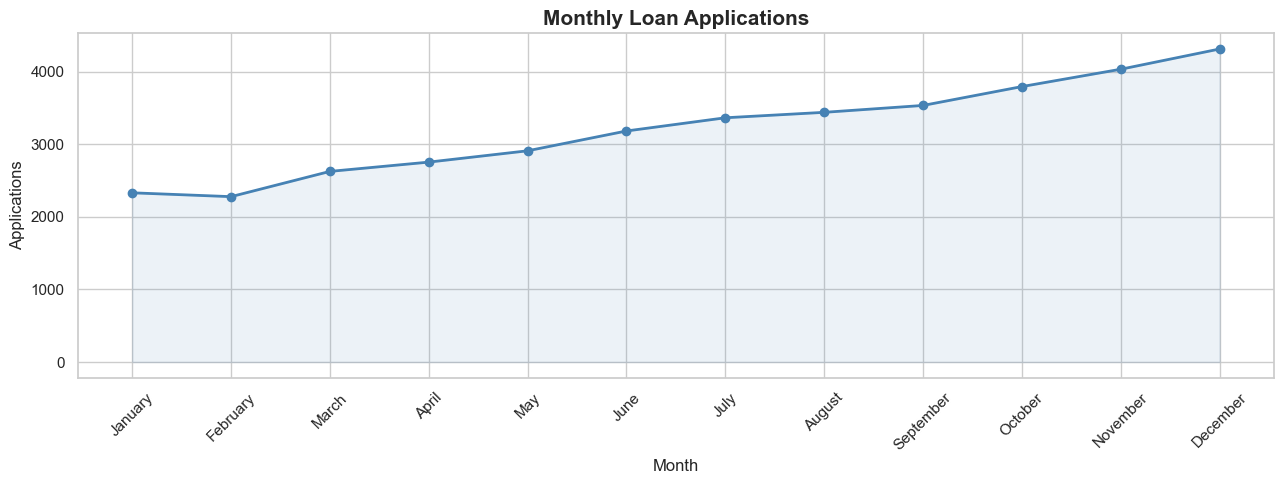

In [9]:
# 1. Monthly Trend - Line Chart
plt.figure(figsize=(13, 5))
plt.plot(monthly['month_name'], monthly['Total_Applications'], 
         marker='o', color='steelblue', linewidth=2)
plt.fill_between(monthly['month_name'], monthly['Total_Applications'], 
                 alpha=0.1, color='steelblue')
plt.title('Monthly Loan Applications', fontsize=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Applications')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()

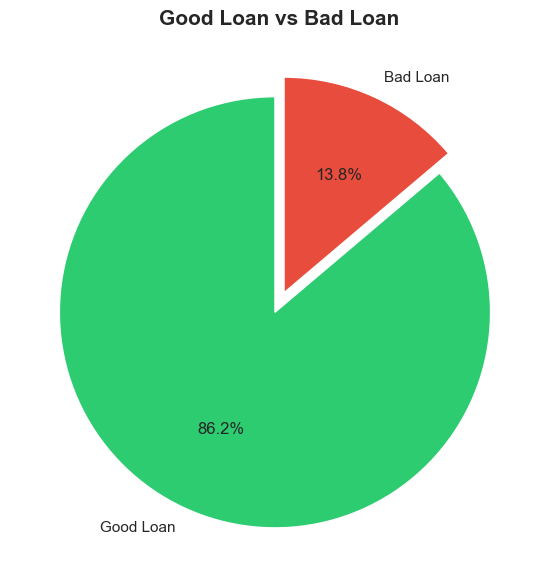

In [10]:
# 2. Good vs Bad Loan - Pie Chart
plt.figure(figsize=(7, 7))
plt.pie([good_pct, bad_pct],
        labels=['Good Loan', 'Bad Loan'],
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'],
        startangle=90,
        explode=(0.05, 0.05))
plt.title('Good Loan vs Bad Loan', fontsize=15, fontweight='bold')
plt.savefig('loan_quality_pie.png', dpi=150)
plt.show()

C:\Users\saike\AppData\Local\Temp\ipykernel_8060\993235789.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=purpose_wise, y='purpose', x='Total_Applications', palette='Blues_d')


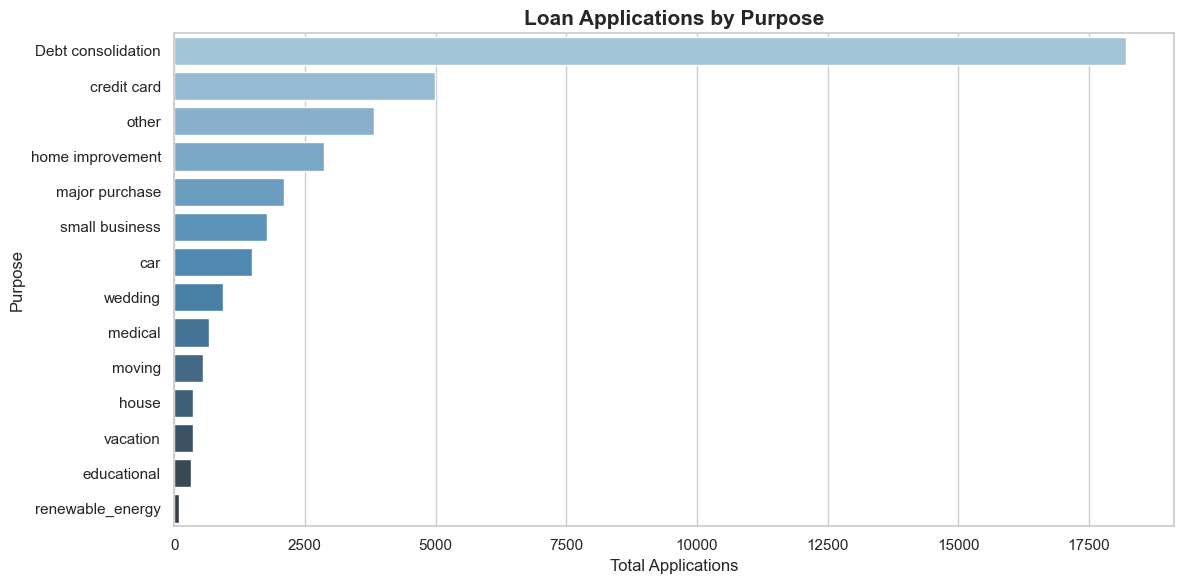

In [11]:
# 3. Purpose wise - Horizontal Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=purpose_wise, y='purpose', x='Total_Applications', palette='Blues_d')
plt.title('Loan Applications by Purpose', fontsize=15, fontweight='bold')
plt.xlabel('Total Applications')
plt.ylabel('Purpose')
plt.tight_layout()
plt.savefig('purpose_bar.png', dpi=150)
plt.show()

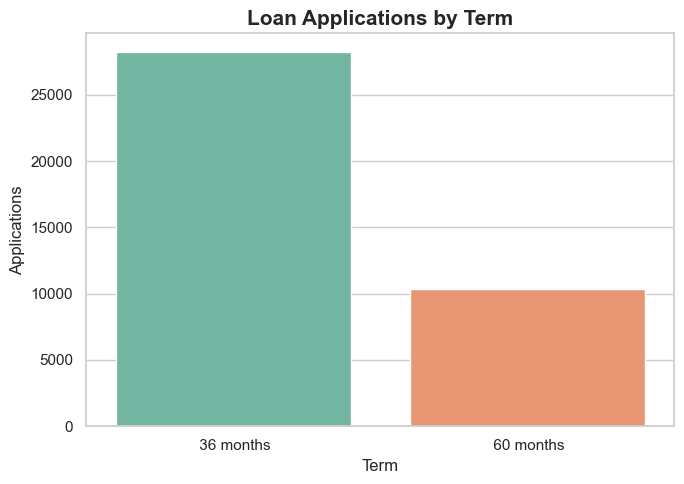

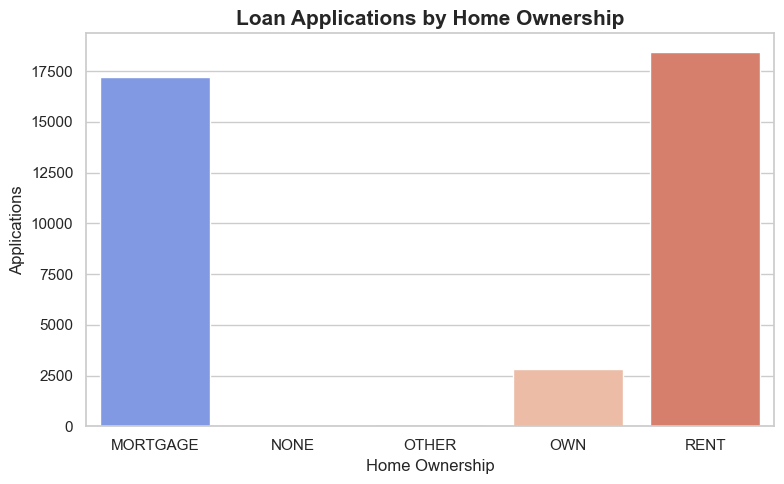

In [12]:
# 4. Term wise - Bar Chart
plt.figure(figsize=(7, 5))
sns.barplot(data=term_wise, x='term', y='Total_Applications', palette='Set2', hue='term', legend=False)
plt.title('Loan Applications by Term', fontsize=15, fontweight='bold')
plt.xlabel('Term')
plt.ylabel('Applications')
plt.tight_layout()
plt.savefig('term_bar.png', dpi=150)
plt.show()

# 5. Home Ownership - Bar Chart
plt.figure(figsize=(8, 5))
sns.barplot(data=home_wise, x='home_ownership', y='Total_Applications', palette='coolwarm', hue='home_ownership', legend=False)
plt.title('Loan Applications by Home Ownership', fontsize=15, fontweight='bold')
plt.xlabel('Home Ownership')
plt.ylabel('Applications')
plt.tight_layout()
plt.savefig('home_ownership.png', dpi=150)
plt.show()

In [13]:
df.to_csv('clean_loan_data.csv', index=False)
monthly.to_csv('monthly_summary.csv', index=False)
state_wise.to_csv('state_summary.csv', index=False)
purpose_wise.to_csv('purpose_summary.csv', index=False)
term_wise.to_csv('term_summary.csv', index=False)
home_wise.to_csv('home_ownership_summary.csv', index=False)
loan_quality.to_csv('good_bad_loan.csv', index=False)
loan_status_summary.to_csv('loan_status_summary.csv', index=False)

print('✅ All CSV files exported! Power BI ki ready!')

✅ All CSV files exported! Power BI ki ready!


In [14]:
import os
print(os.getcwd())

C:\Users\saike


In [15]:
import os
print(os.getcwd())

C:\Users\saike
